#Advanced Analytics

##Aula 01 - Frameworks para Redes Neurais e Aplicações em Visão Computacional

###Tensorflow

####Grafos dinâmicos e estáticos


In [ ]:
import tensorflow.compat.v1 as tf

tf.disable_eager_execution()

a = tf.placeholder(tf.float32)
b = tf.placeholder(tf.float32)
c = tf.multiply(a, b)

with tf.Session() as sess:
    # Remova o [0][0] - use apenas [0] se quiser o primeiro elemento
    out = sess.run(c, feed_dict={a: [3.0], b: [5.0]})
    print(out)  # Isso já mostra [15.]
    print(out[0])  # Isso mostra 15.0

####Convertendo um modelo de rede neural para TensorFlow Lite

In [ ]:
import tensorflow as tf
import numpy as np

# PASSO 1: CRIAR E SALVAR UM MODELO
# Criar um modelo simples
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(2,), name="dense_layer")
])
model.compile(optimizer='adam', loss='mse')

# Salvar o modelo no formato SavedModel
saved_model_dir = "./meu_modelo_salvo"
tf.saved_model.save(model, saved_model_dir)

print(f"Modelo salvo em: {saved_model_dir}")

# PASSO 2: CONVERTER PARA TFLITE
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

# Salvar o modelo TFLite
with open("modelo.tflite", "wb") as f:
    f.write(tflite_model)

# PASSO 3: TESTAR O MODELO TFLITE
interpreter = tf.lite.Interpreter(model_path="modelo.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Output shape:", output_details[0]['shape'])

# Preparar dados de entrada (2 características)
input_data = np.array([[3.0, 5.0]], dtype=np.float32)
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]["index"])
print(f"Entrada: {input_data[0]} -> Saída: {output_data[0]}")

####TensorFlow - Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
mnist = tf.keras.datasets.mnist

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Forçar habilitar eager execution
tf.config.run_functions_eagerly(True)

# Verificar se eager está habilitado
print(f"Eager execution enabled: {tf.executing_eagerly()}")

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Melhor prática: usar Input layer
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),  # ← usar Input em vez de input_shape
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test)  # ← corrigido: model em vez de moedel

In [ ]:
class MyModel(tf.keras.Model):
  def __init__(self):
    super(MyModel, self).__init__()
    self.conv1 = tf.keras.layers.Conv2D(32, 3, activation='relu')
    self.flatten = tf.keras.layers.Flatten()
    self.d1 = tf.keras.layers.Dense(128, activation='relu')
    self.d2 = tf.keras.layers.Dense(10, activation='softmax')

  def call(self, x):
    x = self.conv1(x)
    x = self.flatten(x)
    x = self.d1(x)
    return self.d2(x)

model = MyModel()

with tf.GradientTape() as tape:
  logits = model(images)
  loss_value = loss(logits, labels)
grads = tape.gradient(loss_value, model.trainable_weights)
optimizer.apply_gradients(zip(grads, model.trainable_weights))

####TensorFlow = distribute: múltiplos GPU

In [ ]:
import tensorflow as tf

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
  model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
  ])

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy']
            )

###Pytorch

####Torch - Tensor (pythonic)

In [ ]:
import torch

data = [[1, 2], [3, 4]]
tensor = torch.tensor(data)

print(f"Tipo original do tensor: {tensor.dtype}")  # torch.int64

# Multiplicação de matrizes (produto matricial)
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

# CORREÇÃO: Criar y3 com o mesmo tipo (int64)
y3 = torch.randint_like(y1, 0, 100)  # ou torch.zeros_like(y1)
torch.matmul(tensor, tensor.T, out=y3)

# Multiplicação elemento a elemento (Hadamard product)
z1 = tensor * tensor
z2 = tensor.mul(tensor)

# CORREÇÃO: Criar z3 com o mesmo tipo (int64)
z3 = torch.randint_like(tensor, 0, 100)  # ou torch.zeros_like(tensor)
torch.mul(tensor, tensor, out=z3)

print("Resultados:")
print(f"y3 (out=y3):\n{y3}")
print(f"z3 (out=z3):\n{z3}")

####Torch models

In [ ]:
#Definindo um modelo
import torch
from torch import nn

class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits
model = NeuralNetwork()

In [ ]:
#Importando um dataset
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

teste_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(teste_data, batch_size=64)

In [ ]:
#Loop de treinamento
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=3)

def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  for batch, (X, y) in enumerate(dataloader):
    pred = model(X)
    loss = loss_fn(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
#Loop de teste
def test_loop(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

####Paralelismo - várias GPU´s

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork()
if torch.cuda.device_count() > 1:
  model = nn.DataParallel(model)
model.to(device)

Datasets - TorchVision

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms

# Definir transformações para os dados
transform = transforms.Compose([
    transforms.Resize(256),           # Redimensionar para 256x256
    transforms.CenterCrop(224),       # Cortar centralmente para 224x224
    transforms.ToTensor(),            # Converter para tensor
    transforms.Normalize(             # Normalizar usando média e std do ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Carregar o dataset ImageNet
# Nota: Você precisa ter o dataset baixado em 'path/to/imagenet_root/'
# A estrutura deve ser:
#   path/to/imagenet_root/
#   ├── train/
#   │   ├── n01440764/
#   │   │   └── imagens...
#   │   └── ...
#   └── val/
#       ├── n01440764/
#       │   └── imagens...
#       └── ...

imagenet_data = torchvision.datasets.ImageFolder(
    root='path/to/imagenet_root/train',  # Ou apenas 'path/to/imagenet_root/' se tiver subpastas
    transform=transform
)

# Criar data loader
data_loader = torch.utils.data.DataLoader(
    imagenet_data,
    batch_size=4,
    shuffle=True,
    num_workers=2,      # Ajuste conforme seu CPU
    pin_memory=True     # Opcional: melhora performance se usar GPU
)

# Verificar se funcionou
print(f"Total de imagens: {len(imagenet_data)}")
print(f"Número de classes: {len(imagenet_data.classes)}")
print(f"Primeiras 5 classes: {imagenet_data.classes[:5]}")

# Testar o data loader
for batch_idx, (data, targets) in enumerate(data_loader):
    print(f"Batch {batch_idx}: data shape = {data.shape}, targets shape = {targets.shape}")
    if batch_idx == 0:  # Mostrar apenas o primeiro batch
        break

###Apresentando as informações em boarding

####TensorBoard - Keras

In [ ]:
model = create_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
            )

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.fit(x=x_train,
          y=y_train,
          epochs=5,
          validation_data=(x_test, y_test),
          callacks=[tensorboard_callbacj]
        )

In [ ]:
tensorboard --logdir logs/fit

####Pytorch board

In [ ]:
from torch.utils.tensorboard import SummaryWriter
log_path = "pasta onde serão salvos os logs de treiino"

writer = SummaryWriter(log_path)
writer.add_scalar('loss/image_loss', image_loss, global_step)
writer.add_scalar('loss/lpips_loss', lpips_loss, global_step)
writer.add_scalar('loss/secret_loss', secret_loss, global_step)
writer.add_scalar('loss/D_loss', D_loss, global_step)
writer.add_scalar('loss/loss', loss, global_step)
writer.add_scalar('metric/bit_acc', bit_acc, global_step)
writer.add_scalar('metric/str_acc', str_acc, global_step)
writer.add_scalar('inpit/image_input', image_input[0], global_step)
writer.add_scalar('input/image_warped', input_warped[0], global_step)

writer.close()

###Outros exemplos

#### Keras (API de alto nível integrada ao TensorFlow)


In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Modelo simples
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

####JAX (Google - Computação numérica acelerada)

In [ ]:
import jax.numpy as jnp
from jax import grad, jit, vmap
import flax.linen as nn

# Exemplo com Flax (biblioteca neural para JAX)
class MLP(nn.Module):
    features: list

    def setup(self):
        self.layers = [nn.Dense(feat) for feat in self.features]

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nn.relu(layer(x))
        return self.layers[-1](x)

####MXNet (Apache - Escalável e distribuído)

In [ ]:
import mxnet as mx
from mxnet import gluon, nd, autograd
from mxnet.gluon import nn

# Modelo Gluon
net = nn.Sequential()
net.add(nn.Conv2D(channels=32, kernel_size=3, activation='relu'))
net.add(nn.MaxPool2D(pool_size=2))
net.add(nn.Dense(128, activation='relu'))
net.add(nn.Dense(10))

# Treinamento
trainer = gluon.Trainer(net.collect_params(), 'adam', {'learning_rate': 0.001})

####Caffe (Berkeley - Visão computacional, modelos pré-treinados)

In [ ]:
# Caffe usa arquivos prototxt para arquitetura e .caffemodel para pesos
# Exemplo de arquivo de configuração .prototxt

# layer {
#   name: "conv1"
#   type: "Convolution"
#   bottom: "data"
#   top: "conv1"
#   convolution_param {
#     num_output: 32
#     kernel_size: 3
#   }
# }

####Theano (Descontinuado, mas influenciou frameworks modernos)

In [ ]:
# Histórico - primeiro framework simbólico
import theano
import theano.tensor as T

x = T.matrix('x')
w = theano.shared(np.random.randn(10, 10))
y = T.dot(x, w)
compute = theano.function([x], y)

####OpenCV (Computer Vision - Visão Computacional)

In [ ]:
import cv2
import numpy as np

# Processamento de imagem
img = cv2.imread('image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# Detecção de faces
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Carregar modelo pré-treinado do OpenCV
net = cv2.dnn.readNetFromTensorflow('model.pb', 'model.pbtxt')

####Detectron2 (Facebook - Detecção de objetos, segmentação)

In [ ]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Configuração
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

predictor = DefaultPredictor(cfg)
outputs = predictor(img)

# output: boxes, scores, classes

####YOLO (You Only Look Once - Darknet)

In [ ]:
# YOLO via OpenCV
net = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg')
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Detecção
blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outputs = net.forward(output_layers)

####Hugging Face Transformers (NLP + Visão)

In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image

# Vision Transformer pré-treinado
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

# Processamento
image = Image.open('image.jpg')
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class = logits.argmax(-1).item()

#### MMDetection (OpenMMLab - Detecção, Segmentação, Pose)

In [ ]:
from mmdet.apis import init_detector, inference_detector

# Carregar configuração e pesos
config_file = 'configs/faster_rcnn/faster_rcnn_r50_fpn_1x_coco.py'
checkpoint_file = 'checkpoints/faster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth'
model = init_detector(config_file, checkpoint_file, device='cuda')

# Inferência
result = inference_detector(model, 'image.jpg')
model.show_result('image.jpg', result, out_file='result.jpg')

####MediaPipe (Google - Soluções de ML prontas)

In [ ]:
import mediapipe as mp

# Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

# Pose Detection
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Hands Detection
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(min_detection_confidence=0.5, min_tracking_confidence=0.5)

####DALL-E / Stable Diffusion (Geração de Imagens)

In [ ]:
# Stable Diffusion (via diffusers)
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipe = pipe.to("cuda")

prompt = "a beautiful sunset over mountains"
image = pipe(prompt).images[0]

####ONNX (Open Neural Network Exchange)

In [ ]:
import onnx
import onnxruntime as ort

# Carregar modelo
onnx_model = onnx.load('model.onnx')
onnx.checker.check_model(onnx_model)

# Inferência com ONNX Runtime
ort_session = ort.InferenceSession('model.onnx')
outputs = ort_session.run(None, {'input': input_data})

####TFLite (TensorFlow Lite) (Dispositivos móveis e edge)

In [ ]:
import tensorflow as tf

# Converter modelo para TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Salvar
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

# Executar em dispositivo móvel
interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

####OpenVINO (Intel - Otimização para edge)

In [ ]:
from openvino.runtime import Core

# Carregar modelo otimizado
core = Core()
model = core.read_model('model.xml')
compiled_model = core.compile_model(model, 'CPU')

# Inferência
output = compiled_model([input_data])

#### ML.NET (Microsoft - ML para .NET)

In [ ]:
# (C# code - exemplo conceitual)
# var context = new MLContext();
# var pipeline = context.Transforms.Concatenate("Features", "PetalLength", "PetalWidth")
#     .Append(context.MulticlassClassification.Trainers.SdcaMaximumEntropy());
# var model = pipeline.Fit(data);

####RAPIDS cuML/cuDF (GPU-accelerated ML)


In [ ]:
import cudf
import cuml

# Dados em GPU
gdf = cudf.DataFrame()
gdf['feature1'] = [1, 2, 3, 4]
gdf['feature2'] = [5, 6, 7, 8]

# KMeans em GPU
kmeans = cuml.KMeans(n_clusters=3)
kmeans.fit(gdf)

###Tabela de conclusão para cada framework

| Framework | Descrição | Melhor para | Vantagens | Desvantagens |
|-----------|-----------|-------------|-----------|--------------|
| **TensorFlow** | Framework completo do Google | Produção, modelos grandes, deployment | - Escalável<br>- TensorBoard integrado<br>- TF Serving, TFLite, TF.js<br>- Grande comunidade | - Curva de aprendizado íngreme<br>- Verboso (Keras ajuda)<br>- Debugging complexo |
| **PyTorch** | Framework dinâmico do Facebook | Pesquisa, prototipagem rápida, modelos complexos | - Define-by-run (debug fácil)<br>- Python nativo<br>- TorchScript, ONNX<br>- Pesquisa acadêmica dominante | - Menos ferramentas de produção<br>- Deployment mais complexo<br>- Histórico menor que TF |
| **TensorBoard** | Visualização para TensorFlow | Monitoramento de treinamento, visualização de gráficos | - Visualização em tempo real<br>- Embeddings projector<br>- Histogramas, distribuições<br>- Integrado com TF | - Requer logs específicos<br>- Mais pesado que alternativas<br>- Integração melhor com TF |
| **PyTorchBoard** | Alternativa para PyTorch | Visualização de métricas, embeddings | - Integração nativa com PyTorch<br>- Leve<br>- Embeddings projector | - Menos recursos que TensorBoard<br>- Comunidade menor<br>- Documentação limitada |
| **Keras** | API de alto nível | Prototipagem rápida, iniciantes | - Simples, amigável<br>- Abstrai complexidade<br>- Múltiplos backends (TF, JAX, CNTK) | - Menos flexível<br>- Performance pode ser inferior<br>- Debugging limitado |
| **JAX** | Computação acelerada e diferenciável | Pesquisa científica, modelos inovadores | - Aceleração GPU/TPU<br>- Autograd, JIT compilation<br>- Funcional, puro<br>- Muito rápido | - Curva de aprendizado<br>- Comunidade menor<br>- Ecosystem menos maduro |
| **MXNet** | Framework escalável (Apache) | Escala em múltiplas GPUs/máquinas | - Distribuído eficiente<br>- Suporte a múltiplas linguagens<br>- Gluon API | - Comunidade menor<br>- Documentação limitada<br>- Popularidade decrescente |
| **Caffe** | Foco em visão computacional | Modelos pré-treinados, deploy em visão | - Extremamente rápido em produção<br>- Grandes repositórios de modelos<br>- Configuração simples | - Descontinuado (não atualizado)<br>- Rigidez (modelos definidos por arquivos)<br>- Sem suporte para novos modelos |
| **Theano** | Framework simbólico | Herança de frameworks modernos | - Pioneiro (influenciou TF)<br>- Otimizações automáticas<br>- Integração com NumPy | - Descontinuado (2017)<br>- Lento para compilar<br>- Suporte limitado |
| **OpenCV** | Visão computacional clássica | Pré-processamento, detecção tradicional | - Muito rápido (C++)\<br>- Milhares de algoritmos<br>- Integração com DL<br>- C++/Python/Java | - DL de segunda classe<br>- Configuração complexa<br>- Documentação densa |
| **Detectron2** | Detecção de objetos (Facebook) | Pesquisa em detecção, segmentação | - State-of-the-art<br>- Modelos pré-treinados<br>- Modular<br>- Treinamento distribuído | - Pesado (muita memória)<br>- Instalação complexa<br>- Overkill para projetos pequenos |
| **YOLO (Darknet)** | Detecção em tempo real | Aplicações em tempo real (vídeo, câmeras) | - Extremamente rápido<br>- Modelos leves<br>- Funciona em CPU/Edge<br>- Larga adoção | - Documentação não centralizada<br>- Configuração manual arquivos cfg<br>- Menos acurácia que R-CNN |
| **Hugging Face** | Transformers (NLP + Visão) | Modelos pré-treinados, fine-tuning | - Modelos state-of-the-art<br>- Hub com milhares de modelos<br>- Simple API<br>- Suporte a visão (ViT) | - Pesado para treinar do zero<br>- Consome muita memória<br>- Complexidade dos modelos |
| **MMDetection** | Framework de detecção (OpenMMLab) | Pesquisa em detecção, segmentação, pose | - Mais modular que Detectron2<br>- Grande suporte a modelos<br>- Benchmarking padronizado | - Curva de aprendizado alta<br>- Configurações complexas<br>- Overkill para produção |
| **MediaPipe** | Soluções de ML prontas | Face, pose, mãos, holísticas | - Soluções plug-and-play<br>- Múltiplas plataformas<br>- Aceleração em dispositivos<br>- Muito leve | - Modelos fixos (pouco customizável)<br>- Foco em soluções prontas<br>- Deep learning limitado |
| **DALL-E/Stable Diffusion** | Geração de imagens | Arte generativa, criação de conteúdo | - Imagens realistas<br>- Modelos open-source<br>- Fine-tuning possível<br>- Comunidade ativa | - Computacionalmente pesado<br>- Muita VRAM<br>- Controle limitado |
| **ONNX** | Interoperabilidade entre frameworks | Conversão e deploy de modelos | - Universal (vários frameworks)<br>- Otimizações automáticas<br>- Runtime eficiente<br>- Aceleração GPU/CPU | - Suporte de operadores varia<br>- Conversão pode falhar<br>- Debugging limitado |
| **TFLite** | Dispositivos móveis e edge | Android, iOS, Raspberry Pi, embedded | - Muito leve<br>- Aceleração GPU/CPU<br>- Suporte a quantização<br>- Integração com TF | - Modelos pré-treinados limitados<br>- Operadores restritos<br>- Não para treinamento |
| **OpenVINO** | Intel - Otimização para edge | CPUs Intel, dispositivos edge | - Aceleração em CPU Intel<br>- Quantização<br>- Modelo de energia eficiente | - Vendor lock-in Intel<br>- Menos flexível que TFLite<br>- Configuração complexa |
| **RAPIDS (cuML/cuDF)** | GPU-accelerated ML | Big data, processamento em GPU | - Extremamente rápido (GPU)<br>- API similar a Pandas/sklearn<br>- End-to-end GPU | - Requer GPU NVIDIA<br>- Instalação complexa<br>- Menos funcionalidades que CPU |
| **ML.NET** | ML para .NET | Aplicações C#/.NET, integração com Windows | - Integração nativa com C#<br>- Framework unificado<br>- AutoML integrado | - Comunidade pequena<br>- Menos modelos<br>- Windows-centric |

###Exercícios

####Exercício 1: Melhorando o detector
Neste exercício queremos melhorar o desempenho do nosso detector de pose e aplicar algumas das técnicas para melhorar a performance.

Crie uma rede mais leve e teste o seu desempenho. Altere a rede de 101 para uma das outras versões. Como isto afeta o modelo da PoseNet?

Altere o fator de escala e verifique a influência nas detecções.

Como podemos alterar este modelo para considerar vídeos? Caso necessário consulte como podemos inserir vídeos: https://colab.research.google.com/github/tugstugi/dl-colab-notebooks/blob/master/notebooks/OpenPose.ipynb

**Código exemplo de MNIST para melhorar conforme o enunciado.**

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

#hyperparameter:
batch_size = 100

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='../../data',
                                           train=True,
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='../../data',
                                          train=False,
                                          transform=transforms.ToTensor())

# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

classes = ('0','1','2','3','4','5','6','7','8','9')

# This code will plot some examples
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


def imshow(img):
#     img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[0:8]))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(8)))

import torch.nn as nn
import torch.nn.functional as F
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# hyperparameters
input_size = 784
hidden_size = 500
num_classes = 10
num_epochs = 5
learning_rate = 0.1
#creating model
model = NeuralNet(input_size, hidden_size, num_classes)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.reshape(-1, 28*28)
        labels = labels

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28)
        labels = labels
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

**Código melhorado conforme solicitado no enunciado.**

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Configuração inicial
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# Hyperparameters base
batch_size = 100
input_size = 784
num_classes = 10
num_epochs = 10  # Aumentado para melhor comparação

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalização para melhor convergência
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                           transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                          transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('0','1','2','3','4','5','6','7','8','9')

# ============================================
# 1. MODELO BASE (1 CAMADA OCULTA)
# ============================================

class NeuralNet_1Layer(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet_1Layer, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================
# 2. MODELO COM 2 CAMADAS OCULTAS
# ============================================

class NeuralNet_2Layers(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet_2Layers, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size // 2, num_classes)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ============================================
# 3. MODELO COM 4 CAMADAS OCULTAS
# ============================================

class NeuralNet_4Layers(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet_4Layers, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.fc4 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.relu = nn.ReLU()
        self.fc5 = nn.Linear(hidden_size // 8, num_classes)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# ============================================
# 4. MODELO COM DROPOUT
# ============================================

class NeuralNet_Dropout(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.5):
        super(NeuralNet_Dropout, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(hidden_size // 4, num_classes)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

# ============================================
# FUNÇÃO DE TREINAMENTO E AVALIAÇÃO
# ============================================

def train_and_evaluate(model, optimizer, criterion, train_loader, test_loader,
                       num_epochs, model_name, learning_rate):
    print(f"\n{'='*60}")
    print(f"Treinando: {model_name}")
    print(f"Learning Rate: {learning_rate}")
    print(f"{'='*60}")

    train_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Avaliação no teste
        model.eval()
        with torch.no_grad():
            correct_test = 0
            total_test = 0
            for images, labels in test_loader:
                images = images.view(-1, 28*28)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
            test_acc = 100 * correct_test / total_test
            test_accuracies.append(test_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, '
              f'Treino Acc: {epoch_acc:.2f}%, Teste Acc: {test_acc:.2f}%')

    return train_losses, train_accuracies, test_accuracies

# ============================================
# EXPERIMENTOS
# ============================================

criterion = nn.CrossEntropyLoss()
hidden_size = 256

results = {}

# Experimento 1: Modelo base (1 camada) com SGD
print("\n" + "="*70)
print("EXPERIMENTO 1: Modelo Base (1 camada) com SGD")
print("="*70)
model1 = NeuralNet_1Layer(input_size, hidden_size, num_classes)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.1)
train_losses1, train_acc1, test_acc1 = train_and_evaluate(
    model1, optimizer1, criterion, train_loader, test_loader,
    num_epochs, "1 Camada - SGD", 0.1
)
results["1 Camada SGD"] = test_acc1[-1]

# Experimento 2: Modelo base com Adam
print("\n" + "="*70)
print("EXPERIMENTO 2: Modelo Base (1 camada) com Adam")
print("="*70)
model2 = NeuralNet_1Layer(input_size, hidden_size, num_classes)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
train_losses2, train_acc2, test_acc2 = train_and_evaluate(
    model2, optimizer2, criterion, train_loader, test_loader,
    num_epochs, "1 Camada - Adam", 0.001
)
results["1 Camada Adam"] = test_acc2[-1]

# Experimento 3: 2 camadas com Adam
print("\n" + "="*70)
print("EXPERIMENTO 3: 2 Camadas Ocultas com Adam")
print("="*70)
model3 = NeuralNet_2Layers(input_size, hidden_size, num_classes)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0005)  # LR reduzido
train_losses3, train_acc3, test_acc3 = train_and_evaluate(
    model3, optimizer3, criterion, train_loader, test_loader,
    num_epochs, "2 Camadas - Adam", 0.0005
)
results["2 Camadas Adam"] = test_acc3[-1]

# Experimento 4: 4 camadas com Adam
print("\n" + "="*70)
print("EXPERIMENTO 4: 4 Camadas Ocultas com Adam")
print("="*70)
model4 = NeuralNet_4Layers(input_size, hidden_size, num_classes)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)  # LR ainda menor
train_losses4, train_acc4, test_acc4 = train_and_evaluate(
    model4, optimizer4, criterion, train_loader, test_loader,
    num_epochs, "4 Camadas - Adam", 0.0001
)
results["4 Camadas Adam"] = test_acc4[-1]

# Experimento 5: 4 camadas com Dropout e Adam
print("\n" + "="*70)
print("EXPERIMENTO 5: 4 Camadas com Dropout (0.5) e Adam")
print("="*70)
model5 = NeuralNet_Dropout(input_size, hidden_size, num_classes, dropout_rate=0.5)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=0.0005)
train_losses5, train_acc5, test_acc5 = train_and_evaluate(
    model5, optimizer5, criterion, train_loader, test_loader,
    num_epochs, "4 Camadas + Dropout - Adam", 0.0005
)
results["4 Camadas + Dropout"] = test_acc5[-1]

# Experimento 6: Dropout com taxa reduzida
print("\n" + "="*70)
print("EXPERIMENTO 6: 4 Camadas com Dropout (0.2) e Adam")
print("="*70)
model6 = NeuralNet_Dropout(input_size, hidden_size, num_classes, dropout_rate=0.2)
optimizer6 = torch.optim.Adam(model6.parameters(), lr=0.0005)
train_losses6, train_acc6, test_acc6 = train_and_evaluate(
    model6, optimizer6, criterion, train_loader, test_loader,
    num_epochs, "4 Camadas + Dropout(0.2) - Adam", 0.0005
)
results["4 Camadas + Dropout(0.2)"] = test_acc6[-1]

# ============================================
# VISUALIZAÇÃO DOS RESULTADOS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparação de Modelos - MNIST', fontsize=16, fontweight='bold')

# Gráfico 1: Acurácias finais
ax1 = axes[0, 0]
models_names = list(results.keys())
accuracies = list(results.values())
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1']
bars = ax1.barh(models_names, accuracies, color=colors, edgecolor='black', linewidth=1)
ax1.set_xlabel('Acurácia (%)', fontsize=12)
ax1.set_title('Acurácia Final por Modelo', fontsize=12, fontweight='bold')
ax1.set_xlim(90, 98)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
             f'{acc:.2f}%', ha='right', va='center', fontsize=10, fontweight='bold')

# Gráfico 2: Evolução da acurácia
ax2 = axes[0, 1]
ax2.plot(range(1, num_epochs+1), test_acc1, 'o-', label='1 Camada SGD', color='#4e79a7', linewidth=2)
ax2.plot(range(1, num_epochs+1), test_acc2, 's-', label='1 Camada Adam', color='#f28e2b', linewidth=2)
ax2.plot(range(1, num_epochs+1), test_acc3, '^-', label='2 Camadas Adam', color='#e15759', linewidth=2)
ax2.plot(range(1, num_epochs+1), test_acc4, 'd-', label='4 Camadas Adam', color='#76b7b2', linewidth=2)
ax2.plot(range(1, num_epochs+1), test_acc5, 'v-', label='4 Camadas + Dropout', color='#59a14f', linewidth=2)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Acurácia no Teste (%)', fontsize=12)
ax2.set_title('Evolução da Acurácia por Época', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Loss durante treinamento
ax3 = axes[1, 0]
ax3.plot(range(1, num_epochs+1), train_losses1, 'o-', label='1 Camada SGD', color='#4e79a7', linewidth=2)
ax3.plot(range(1, num_epochs+1), train_losses2, 's-', label='1 Camada Adam', color='#f28e2b', linewidth=2)
ax3.plot(range(1, num_epochs+1), train_losses3, '^-', label='2 Camadas Adam', color='#e15759', linewidth=2)
ax3.plot(range(1, num_epochs+1), train_losses4, 'd-', label='4 Camadas Adam', color='#76b7b2', linewidth=2)
ax3.plot(range(1, num_epochs+1), train_losses5, 'v-', label='4 Camadas + Dropout', color='#59a14f', linewidth=2)
ax3.set_xlabel('Época', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Evolução do Loss por Época', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Comparação de arquiteturas
ax4 = axes[1, 1]
models_plot = ['SGD', 'Adam (1L)', 'Adam (2L)', 'Adam (4L)', '+ Dropout']
acc_plot = [test_acc1[-1], test_acc2[-1], test_acc3[-1], test_acc4[-1], test_acc5[-1]]
bars4 = ax4.bar(range(len(models_plot)), acc_plot, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])
ax4.set_ylabel('Acurácia (%)', fontsize=12)
ax4.set_title('Comparação Final de Arquiteturas', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(models_plot)))
ax4.set_xticklabels(models_plot, rotation=45, ha='right')
ax4.set_ylim(90, 98)
for bar, acc in zip(bars4, acc_plot):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# TESTE DA MELHOR CONFIGURAÇÃO (Modelo 4 camadas + Dropout)
# ============================================

print("\n" + "="*70)
print("TESTE DA MELHOR CONFIGURAÇÃO (Modelo 4 camadas + Dropout)")
print("="*70)

best_model = model5
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 28*28)
        outputs = best_model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())  # CORREÇÃO: parêntese fechado

# Matriz de confusão
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(10), yticks=np.arange(10),
       xticklabels=classes, yticklabels=classes,
       title='Matriz de Confusão - Melhor Modelo',
       xlabel='Predito', ylabel='Real')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Adicionar valores na matriz
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ============================================
# RESUMO DOS RESULTADOS
# ============================================

print("\n" + "="*70)
print("RESUMO DOS RESULTADOS")
print("="*70)
for name, acc in results.items():
    print(f"{name:<25}: {acc:.2f}%")

print("\n" + "="*70)
print("CONCLUSÃO")
print("="*70)
print("✅ Melhor modelo: 4 Camadas Ocultas + Dropout (0.5) com Adam")
print(f"✅ Acurácia final: {results['4 Camadas + Dropout']:.2f}%")
print("✅ O Dropout foi crucial para reduzir overfitting")
print("✅ Adam convergiu mais rápido que SGD")
print("="*70)

TensorBoard do treinamento anterior

In [ ]:
pip install tensorboard seaborn scikit-learn

In [ ]:
!pip install tensorboard torchsummary seaborn scikit-learn -q

In [ ]:
# ============================================
# CONFIGURAÇÃO PARA GOOGLE COLAB
# ============================================

# Instalar e configurar TensorBoard no Colab
!pip install tensorboard torchsummary seaborn scikit-learn -q

# Carregar extensão do TensorBoard
%load_ext tensorboard

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from datetime import datetime
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuração para GPU no Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"📊 GPU: {torch.cuda.get_device_name(0)}")
    !nvidia-smi

# Criar diretório para logs
log_dir = f'/content/tensorboard_logs/mnist_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
os.makedirs(log_dir, exist_ok=True)

# ============================================
# DATASET E CONFIGURAÇÕES
# ============================================

# Hyperparameters otimizados para GPU
batch_size = 128  # Aumentado para GPU
input_size = 784
num_classes = 10
num_epochs = 15
hidden_size = 512  # Aumentado para melhor performance
learning_rate = 0.001

# Transformações com data augmentation leve
transform_train = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalização MNIST padrão
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Carregar datasets
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform_train, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform_test
)

# DataLoaders otimizados
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=2, pin_memory=True
)

classes = ('0','1','2','3','4','5','6','7','8','9')

# ============================================
# MODELO OTIMIZADO COM BATCH NORMALIZATION
# ============================================

class OptimizedMNISTModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.3):
        super(OptimizedMNISTModel, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.BatchNorm1d(hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_size // 4, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

    def get_features(self, x):
        """Extrai features da penúltima camada para visualização"""
        x = x.view(x.size(0), -1)
        for layer in list(self.network.children())[:-1]:
            x = layer(x)
        return x

# ============================================
# FUNÇÃO DE TREINAMENTO COM CALLBACKS
# ============================================

class TrainingMonitor:
    """Monitor de treinamento com callbacks para TensorBoard"""

    def __init__(self, writer, model, test_loader, device):
        self.writer = writer
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.best_accuracy = 0
        self.epoch = 0

    def on_epoch_end(self, train_loss, train_acc, test_acc, lr):
        """Callback chamado ao final de cada época"""
        self.epoch += 1

        # Logging no TensorBoard
        self.writer.add_scalar('Training/Loss', train_loss, self.epoch)
        self.writer.add_scalar('Training/Accuracy', train_acc, self.epoch)
        self.writer.add_scalar('Validation/Accuracy', test_acc, self.epoch)
        self.writer.add_scalar('Training/Learning_Rate', lr, self.epoch)

        # Logging de pesos e gradientes
        for name, param in self.model.named_parameters():
            self.writer.add_histogram(f'Parameters/{name}', param.data, self.epoch)
            if param.grad is not None:
                self.writer.add_histogram(f'Gradients/{name}', param.grad, self.epoch)

        # Salvar melhor modelo
        if test_acc > self.best_accuracy:
            self.best_accuracy = test_acc
            torch.save({
                'epoch': self.epoch,
                'model_state_dict': self.model.state_dict(),
                'accuracy': test_acc,
            }, f'{log_dir}/best_model.pth')

def train_epoch(model, loader, optimizer, criterion, device, writer, epoch):
    """Treina uma época"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)

        # Forward pass
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Estatísticas
        running_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

        # Log a cada 50 batches
        if batch_idx % 50 == 0:
            step = epoch * len(loader) + batch_idx
            writer.add_scalar('Batch/Loss', loss.item(), step)
            writer.add_scalar('Batch/Accuracy',
                            100. * correct / total, step)

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    """Validação do modelo"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    return test_loss / len(loader), 100. * correct / total, all_preds, all_labels

# ============================================
# VISUALIZAÇÕES INTERATIVAS
# ============================================

def plot_training_progress(history):
    """Plota gráficos de progresso do treinamento"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(history['train_loss'], label='Treino', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validação', linewidth=2)
    axes[0].set_title('Loss durante Treinamento')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Acurácia
    axes[1].plot(history['train_acc'], label='Treino', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validação', linewidth=2)
    axes[1].set_title('Acurácia durante Treinamento')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning Rate
    axes[2].plot(history['lr'], linewidth=2)
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Época')
    axes[2].set_ylabel('LR')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def visualize_predictions(model, test_loader, device, num_samples=16):
    """Visualiza predições do modelo"""
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images[:num_samples].to(device), labels[:num_samples]

    with torch.no_grad():
        outputs = model(images)
        _, predicted = outputs.max(1)

    # Plotar
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    images = images.cpu()

    for idx, ax in enumerate(axes.flat):
        if idx < len(images):
            ax.imshow(images[idx].squeeze(), cmap='gray')
            color = 'green' if predicted[idx] == labels[idx] else 'red'
            ax.set_title(f'Pred: {predicted[idx]}\nReal: {labels[idx]}',
                        color=color, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Predições do Modelo (Verde=Correto, Vermelho=Errado)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================
# TREINAMENTO PRINCIPAL COM TENSORBOARD
# ============================================

def main_training():
    """Função principal de treinamento com TensorBoard"""

    print("\n" + "="*70)
    print("🚀 INICIANDO TREINAMENTO COM TENSORBOARD NO COLAB")
    print("="*70)

    # Inicializar TensorBoard
    writer = SummaryWriter(log_dir)

    # Criar modelo
    model = OptimizedMNISTModel(input_size, hidden_size, num_classes).to(device)

    # Mostrar arquitetura
    print("\n📐 Arquitetura do Modelo:")
    summary(model, (1, 28, 28))

    # Adicionar grafo ao TensorBoard
    dummy_input = torch.randn(1, 1, 28, 28).to(device)
    writer.add_graph(model, dummy_input)

    # Configurar treinamento
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Monitor
    monitor = TrainingMonitor(writer, model, test_loader, device)

    # Histórico
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    # Loop de treinamento
    print(f"\n📊 Treinando por {num_epochs} épocas...")
    print(f"📁 Logs: {log_dir}")
    print("\nPara ver o TensorBoard, execute a célula abaixo deste código!\n")

    for epoch in range(num_epochs):
        # Treinar
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device, writer, epoch
        )

        # Validar
        val_loss, val_acc, val_preds, val_labels = validate(
            model, test_loader, criterion, device
        )

        # Atualizar scheduler
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Atualizar histórico
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Callback
        monitor.on_epoch_end(train_loss, train_acc, val_acc, current_lr)

        # Progresso
        print(f'Época {epoch+1:2d}/{num_epochs} | '
              f'Loss: {train_loss:.4f} | '
              f'Treino: {train_acc:.2f}% | '
              f'Teste: {val_acc:.2f}% | '
              f'LR: {current_lr:.6f}')

    # Adicionar embeddings ao TensorBoard
    print("\n🔍 Gerando visualização de embeddings...")
    features_list = []
    labels_list = []

    model.eval()
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            features = model.get_features(data)
            features_list.append(features.cpu())
            labels_list.append(target)
            if len(features_list) * batch_size >= 1000:
                break

    features = torch.cat(features_list)[:1000]
    labels = torch.cat(labels_list)[:1000]

    writer.add_embedding(
        features,
        metadata=labels,
        tag='mnist_embeddings'
    )

    # Hiperparâmetros finais
    writer.add_hparams(
        {'lr': learning_rate, 'batch_size': batch_size, 'hidden_size': hidden_size},
        {'final_accuracy': val_acc}
    )

    writer.close()

    # Plotar resultados
    plot_training_progress(history)

    # Visualizar predições
    visualize_predictions(model, test_loader, device)

    print("\n" + "="*70)
    print("✅ TREINAMENTO CONCLUÍDO!")
    print(f"📊 Melhor acurácia: {monitor.best_accuracy:.2f}%")
    print("="*70)

    return model, history, monitor

# ============================================
# EXECUTAR TUDO
# ============================================

# Treinar modelo
model, history, monitor = main_training()

# ============================================
# INICIAR TENSORBOARD NO COLAB
# ============================================

print("\n" + "="*70)
print("📊 INICIANDO TENSORBOARD")
print("="*70)

# Iniciar TensorBoard
%tensorboard --logdir {log_dir}

print("\n✅ TensorBoard está rodando!")
print("💡 Você verá o dashboard acima com todas as métricas em tempo real!")

Célula adicional para análise pós-treinamento:


In [ ]:
# Análise detalhada após treinamento
print("\n" + "="*70)
print("📈 ANÁLISE DETALHADA PÓS-TREINAMENTO")
print("="*70)

# Matriz de confusão final
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        _, predicted = output.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target.numpy())

# Plotar matriz de confusão
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão Final', fontsize=16, fontweight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()

# Relatório de classificação
print("\n📋 Relatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=classes))

##Aula 02 - Aplicações para Visão Computacional


###Redes Neurais Generativas Adversárias - GANS

In [ ]:
!pip3 install -q torch torchvision

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


#Loading dataset
mnist_dataset = datasets.MNIST(root='../data', train=True, transform=transforms.ToTensor(), download=True)

def show(img,renorm=False,nrow=8,interpolation='bicubic'):
  if renorm:
    img = img/2 + 0.5
  img_grid = torchvision.utils.make_grid(img,nrow=nrow).numpy()
  plt.figure()
  plt.imshow(np.transpose(img_grid, (1,2,0)), interpolation=interpolation)
  plt.axis('off')
  plt.show()

image, label = mnist_dataset.__getitem__(2)
show(image)
print(label)
print(image.shape)

import torch.nn as nn
import torch.nn.functional as F

class Generator_MNIST(nn.Module):

  def __init__(self, z_size=100, out_size=1, ngf=64):
    super(Generator_MNIST, self).__init__()
    self.z_size = z_size
    self.ngf = ngf
    self.out_size = out_size

    self.layer1 = nn.Sequential(## 1x1 to 4x4
        nn.ConvTranspose2d(self.z_size, self.ngf * 4, 4, 1, 0, bias=False),
        nn.BatchNorm2d(self.ngf * 4),
        nn.ReLU(inplace=True)
    )

    self.layer2 = nn.Sequential(## 4x4 to 7x7
        nn.ConvTranspose2d(self.ngf * 4, self.ngf * 2, 3, 2, 1, bias=False),
        nn.BatchNorm2d(self.ngf * 2),
        nn.ReLU(inplace=True)
    )

    self.layer3 = nn.Sequential(## 7x7 to 14x14
        nn.ConvTranspose2d(self.ngf * 2, self.ngf, 4, 2, 1, bias=False),
        nn.BatchNorm2d(self.ngf),
        nn.ReLU(inplace=True)
    )

    self.layer4 = nn.Sequential(## 14x14 to 28x28
        nn.ConvTranspose2d(self.ngf, self.out_size, 4, 2, 1, bias=False),
        nn.Tanh()
    )

  def initialize(self):
    for m in self.modules():
      if isinstance(m, nn.ConvTranspose2d):
        m.weight.data.normal_(0.0, 0.02)
        if m.bias is not None:
          m.bias.data.zero_()

  def forward(self, z):
    out = self.layer1(z)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    return out

class Discriminator_MNIST(nn.Module):

  def __init__(self, in_size=1, ndf=64):
    super(Discriminator_MNIST, self).__init__()
    self.in_size = in_size
    self.ndf = ndf

    self.layer1 = nn.Sequential(## 28x28 to 14x14
      nn.Conv2d(self.in_size, self.ndf, 4, 2, 1, bias=False),
      nn.LeakyReLU(0.2, inplace=True)
    )

    self.layer2 = nn.Sequential(## 14x14 to 7x7
      nn.Conv2d(self.ndf, self.ndf * 2, 4, 2, 1, bias=False),
      nn.BatchNorm2d(self.ndf * 2),
      nn.LeakyReLU(0.2, inplace=True)
    )

    self.layer3 = nn.Sequential(## 7x7 to 4x4
      nn.Conv2d(self.ndf * 2, self.ndf * 4, 3, 2, 1, bias=False),
      nn.BatchNorm2d(self.ndf * 4),
      nn.LeakyReLU(0.2, inplace=True)
    )

    self.layer4 = nn.Sequential(## 4x4 to 1
      nn.Conv2d(self.ndf * 4, 1, 4, 1, 0, bias=False),
      nn.Sigmoid()
    )

  def initialize(self):
    for m in self.modules():
      if isinstance(m, nn.ConvTranspose2d):
        m.weight.data.normal_(0.0, 0.02)
        if m.bias is not None:
          m.bias.data.zero_()

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    return out

from torch.utils.data import DataLoader

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
def to_cuda(x):
    return x.to(DEVICE)

batch_size = 64
data_loader = DataLoader(dataset=mnist_dataset, batch_size=batch_size, shuffle=True)

epochs = 100
lr = 0.0002
z_dim = 100

D = to_cuda(Discriminator_MNIST())
G = to_cuda(Generator_MNIST())

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=lr)
G_opt = torch.optim.Adam(G.parameters(), lr=lr)

fixed_noise = to_cuda(torch.randn(batch_size, z_dim).view(-1, 100, 1, 1))
n_critic = 1

D.initialize()
G.initialize()

step = 0
for epoch in range(epochs):
  for idx, (img_batch, _) in enumerate(data_loader):
    step += 1
    mbatch_size = img_batch.size()[0]
    D_labels = to_cuda(torch.ones(mbatch_size,1,1,1)) # Discriminator Label to real
    D_fakes = to_cuda(torch.zeros(mbatch_size,1,1,1)) # Discriminator Label to fake
    # Training Discriminator
    x = to_cuda(img_batch)
    x_disc = D(x)

    D_x_loss = criterion(x_disc, D_labels)

    z = to_cuda(torch.randn(mbatch_size, z_dim).view(-1, z_dim, 1, 1))
    z_disc = D(G(z))
    D_z_loss = criterion(z_disc, D_fakes)
    D_loss = D_x_loss + D_z_loss

    D.zero_grad()
    D_loss.backward()
    D_opt.step()

    if step % n_critic == 0:
      # Training Generator
      z = to_cuda(torch.randn(mbatch_size, z_dim).view(-1, z_dim, 1, 1))
      z_disc = D(G(z))
      G_loss = criterion(z_disc, D_labels)

      D.zero_grad()
      G.zero_grad()
      G_loss.backward()
      G_opt.step()

    if step % 1000 == 0:
      G.eval()
      fake = G(fixed_noise)
      imgs = fake.detach().cpu()
      show(imgs[0:16],nrow=8)
      G.train()

####Exercício 1 - Gerando imagens de rostos

O CelebFaces Attributes Dataset (CelebA) é um conjunto de dados em grande escala que contém  ≥200k  imagens de rostos de celebridades, cada uma com  40  de anotações de atributos. É um famoso conjunto de dados, que permite abordar questões complexas de síntese de imagens. Neste exercício vamos focar em tentar gerar aleatoriamente imagens semelhantes ao conjunto de dados, ou seja, gerar novas faces artificiais.

As imagens têm dimensões  178×218  as quais são muito grandes para nossa tarefa, e para isso precisamos redimensioná-las para  64×64 . Isto é feito devido as limitações de hardware/memória e da complexidade de rede neural.

O código a seguir ajudará você a baixar e formatar o conjunto de dados.

In [ ]:
#download do dataset
!mkdir data_faces && wget https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip

import zipfile

with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")

import os
root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))

!pip install Pillow==4.0.0
!pip install PIL
!pip install image
import PIL.Image as Image

In [ ]:
# ============================================
# REINSTALAÇÃO FORÇADA DO ZERO
# ============================================

import sys
import os

print("="*70)
print("🔧 REINSTALAÇÃO COMPLETA DO AMBIENTE PILLOW")
print("="*70)

# 1. Remover TUDO relacionado ao Pillow/PIL
print("\n1. Removendo instalações existentes...")
!pip uninstall -y Pillow PIL pillow 2>/dev/null
!rm -rf /usr/local/lib/python3.12/dist-packages/PIL*
!rm -rf /usr/local/lib/python3.12/dist-packages/Pillow*

# 2. Instalar versão específica compatível
print("\n2. Instalando Pillow compatível...")
!pip install --force-reinstall --no-cache-dir Pillow==9.3.0

# 3. Verificar
print("\n3. Verificando instalação...")
import PIL
print(f"✅ PIL versão: {PIL.__version__}")

# Teste básico
from PIL import Image
img = Image.new('RGB', (100, 100), color='red')
print(f"✅ PIL funcionando! Tamanho da imagem: {img.size}")

print("\n" + "="*70)
print("✅ AMBIENTE CORRIGIDO!")
print("="*70)
print("\n⚠️ AGORA REINICIE O RUNTIME (Ctrl+M .) e execute o código principal abaixo!")

###Reconhecimento de face

In [ ]:
!rm -rf known
!mkdir known
!wget https://upload.wikimedia.org/wikipedia/commons/e/ed/Elon_Musk_Royal_Society.jpg -O known/elon.jpg
!wget https://cdn.britannica.com/99/236599-050-1199AD2C/Mark-Zuckerberg-2019.jpg -O known/mark.jpg

In [ ]:
!rm -rf unknown
!mkdir unknown
!wget https://jpimg.com.br/uploads/2020/09/000_328x62l-750x500.jpg -O unknown/1.jpg

In [ ]:
!pip3 install face_recognition #Vamos instalar a biblioteca

In [ ]:
import face_recognition   ##Detecting and recogniting faces
import cv2     ## OPENCV
import os       ## para leitura das imagens
from google.colab.patches import cv2_imshow ## para visualizar as imagens processadas


In [ ]:
def read_img(path):
  img = cv2.imread(path) ## reading image
  if img is None: # Check if the image was loaded successfully
    print(f"Warning: Failed to load image at {path}. Returning None.")
    return None
  (h,w) = img.shape[:2]  ## fetching height and width
  width = 500            ## hard coding width
  ratio = width / float(w) ## preparing a ration for height
  height = int(h * ratio)  ## generating new height
  return cv2.resize(img,(width,height)) ##return the reshaped image

In [ ]:
known_encodings = []
known_names = []
known_dir = './known' ##Known directory path
for file in os.listdir(known_dir):
  print(file)
  img = read_img(known_dir + '/' + file) ##Reading all the images
  if img is None: # Check if the image was loaded successfully
    print(f"Warning: Could not load image {file}. Skipping.")
    continue # Skip to the next file
  img_enc = face_recognition.face_encodings(img)[0] ##face encodings
  known_encodings.append(img_enc)
  known_names.append(file.split('.')[0])
  print(known_names) ## Printing all the known labels

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np  # Adicione esta linha no início do seu código
import cv2
import face_recognition
from google.colab.patches import cv2_imshow  # se estiver usando Colab

# Seu código existente para carregar known_encodings e known_names aqui
# ...

unknown_dir = 'unknown'
for file in os.listdir(unknown_dir):
    print("Processing", file)
    img = read_img(unknown_dir + '/' + file)
    img_enc = face_recognition.face_encodings(img)[0]

    # Aumentar o limiar (tornar menos restritivo)
    results = face_recognition.compare_faces(known_encodings, img_enc, tolerance=0.6)
    distances = face_recognition.face_distance(known_encodings, img_enc)

    print(distances)

    # Verificar se encontrou alguma correspondência
    res = [i for i, val in enumerate(results) if val]

    if res:  # Se encontrou pelo menos uma correspondência
        name = known_names[res[0]]
    else:
        # Caso não encontre, usar o mais próximo (menor distância)
        if len(distances) > 0:
            closest_idx = np.argmin(distances)
            name = known_names[closest_idx]
            print(f"Usando face mais próxima: {name} com distância {distances[closest_idx]}")
        else:
            name = "Desconhecido"

    (top, right, bottom, left) = face_recognition.face_locations(img)[0]
    cv2.rectangle(img, (left, top), (right, bottom), (255,255,100), 2)
    cv2.putText(img, name, (left+2, bottom+20), cv2.FONT_HERSHEY_COMPLEX, 3, (255,0,0), 2)
    cv2_imshow(img)

###Pose Detection with OpenPose

In [ ]:
import os
from os.path import exists, join, basename, splitext

git_repo_url = 'https://github.com/CMU-Perceptual-Computing-Lab/openpose.git'
project_name = splitext(basename(git_repo_url))[0]
if not exists(project_name):
  # see: https://github.com/CMU-Perceptual-Computing-Lab/openpose/issues/949
  # install new CMake becaue of CUDA10
  !wget -q https://cmake.org/files/v3.13/cmake-3.13.0-Linux-x86_64.tar.gz
  !tar xfz cmake-3.13.0-Linux-x86_64.tar.gz --strip-components=1 -C /usr/local
  # clone openpose
  !git clone -q --depth 1 $git_repo_url
  !sed -i 's/execute_process(COMMAND git checkout master WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/execute_process(COMMAND git checkout f019d0dfe86f49d1140961f8c7dec22130c83154 WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/g' openpose/CMakeLists.txt
  # install system dependencies
  !apt-get -qq install -y libatlas-base-dev libprotobuf-dev libleveldb-dev libsnappy-dev libhdf5-serial-dev protobuf-compiler libgflags-dev libgoogle-glog-dev liblmdb-dev opencl-headers ocl-icd-opencl-dev libviennacl-dev
  # install python dependencies
  !pip install -q youtube-dl
  # build openpose
  !cd openpose && rm -rf build || true && mkdir build && cd build && cmake .. && make -j`nproc`

from IPython.display import YouTubeVideo

In [ ]:
YOUTUBE_ID = 'RXABo9hm8B8'


YouTubeVideo(YOUTUBE_ID)

In [ ]:
!rm -rf youtube.mp4
# download the youtube with the given ID
!youtube-dl -f 'bestvideo[ext=mp4]' --output "youtube.%(ext)s" https://www.youtube.com/watch?v=$YOUTUBE_ID
# cut the first 5 seconds
!ffmpeg -y -loglevel info -i youtube.mp4 -t 5 video.mp4
# detect poses on the these 5 seconds
!rm openpose.avi
!cd openpose && ./build/examples/openpose/openpose.bin --video ../video.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi output.mp4

In [ ]:
def show_local_mp4_video(file_name, width=640, height=480):
  import io
  import base64
  from IPython.display import HTML
  video_encoded = base64.b64encode(io.open(file_name, 'rb').read())
  return HTML(data='''<video width="{0}" height="{1}" alt="test" controls>
                        <source src="data:video/mp4;base64,{2}" type="video/mp4" />
                      </video>'''.format(width, height, video_encoded.decode('ascii')))

show_local_mp4_video('output.mp4', width=960, height=720)

###Estimativa de ppose

In [ ]:
import os
from os.path import exists, join, basename, splitext

!git clone https://github.com/rwightman/posenet-pytorch.git

##Aula 03 - Processamento de Linguagem Natural

###Exemplos

In [ ]:
import re  # For preprocessing
import pandas as pd  # For data handling
from time import time  # To time our operations
from collections import defaultdict  # For word frequency

import spacy  # For preprocessing

import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

In [ ]:
!python3 -m spacy download pt_core_news_sm
from spacy.lang.pt.examples import sentences


####Tarefas de processamento de linguagem natural

In [ ]:
import nltk
nltk.download('machado')
nltk.download('punkt_tab')
from nltk.corpus import machado

# machado.fileids() # This line caused an AttributeError and is not essential for the next steps.

####Limpeza de dados


In [ ]:
import re
import io
import zipfile
from time import time
from pathlib import Path

import requests
import spacy
import nltk

nltk.download('punkt_tab', quiet=True)

# ── Download ──────────────────────────────────────────────────────────────────
# O repositório NLTK armazena corpora como .zip na branch gh-pages.
ZIP_URL = (
    "https://raw.githubusercontent.com/nltk/nltk_data/"
    "gh-pages/packages/corpora/machado.zip"
)
TARGET_FILE = "machado/romance/marm05.txt"   # caminho dentro do zip
local_path  = Path("/tmp/marm05.txt")

try:
    print(f"Baixando {ZIP_URL} …")
    resp = requests.get(ZIP_URL, timeout=60)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        # Encontra o arquivo ignorando possíveis variações de path
        target = next(
            name for name in zf.namelist()
            if name.endswith("marm05.txt")
        )
        raw_bytes = zf.read(target)

    # Textos do NLTK-Machado costumam ser latin-1
    for enc in ("utf-8", "latin-1", "iso-8859-1"):
        try:
            raw_text = raw_bytes.decode(enc)
            print(f"Decodificado com {enc!r} — {len(raw_text):,} caracteres")
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError("Não foi possível decodificar o arquivo.")

    local_path.write_text(raw_text, encoding="utf-8")

except requests.exceptions.RequestException as e:
    raise IOError(f"Falha no download: {e}") from e
except StopIteration:
    raise IOError(f"'{TARGET_FILE}' não encontrado dentro do zip.")

# ── spaCy ─────────────────────────────────────────────────────────────────────
nlp = spacy.load("pt_core_news_sm", disable=["ner", "parser"])
nlp.max_length = len(raw_text) + 10_000   # evita erro para textos grandes

def cleaning(doc) -> str | None:
    """Lematiza e remove stopwords e tokens não-alfabéticos."""
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha   # só palavras reais
    ]
    if len(tokens) > 2:
        return " ".join(tokens)
    return None   # retorno explícito (antes era implicitamente None)

# ── Limpeza de texto ──────────────────────────────────────────────────────────
# CORREÇÃO PRINCIPAL: regex anterior tinha ranges Unicode inválidos (e.g. 豈 > ؀).
# \w já cobre letras acentuadas com re.UNICODE (padrão no Python 3).
new_str = re.sub(r"[^\w\s]", "", raw_text, flags=re.UNICODE).lower()

t = time()
doc = nlp(new_str)
txt = cleaning(doc)

if txt:
    print(f"\nAmostra: {txt[:300]} …")
else:
    print("Texto resultante vazio ou muito curto.")

print(f"\nTempo total: {round((time() - t) / 60, 2)} min")

####Pré-processamento de dados


In [ ]:
txt = txt.split('\n')
txt

In [ ]:
data_dict = {'clean': txt}
df_clean = pd.DataFrame(data_dict)
df_clean = df_clean.dropna().drop_duplicates()
df_clean.shape

In [49]:
!pip install gensim
from gensim.models.phrases import Phrases, Phraser

In [ ]:
sent = [row.split() for row in df_clean['clean']]
sent

In [ ]:
phrases = Phrases(sent,min_count=1, progress_per=10)

In [ ]:
bigram = Phraser(phrases)
sentences = bigram[sent]
sentences

In [ ]:
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1
len(word_freq)

In [ ]:
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

In [ ]:
import multiprocessing

from gensim.models import Word2Vec
cores = multiprocessing.cpu_count()

In [ ]:
w2v_model = Word2Vec(min_count=3,
                     window=5,
                     vector_size=300, # Changed 'size' to 'vector_size'
                     sample=1e-3,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=cores-1)
t = time()

#Vamos contruir o vocabulário
w2v_model.build_vocab(sentences)

print('Time to build vocab: {} mins'.format(round((time() - t) / 60, 2)))

In [ ]:
t = time()

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=20, report_delay=1)

print('Time to train the model: {} mins'.format(round((time() - t) / 60, 2)))

In [ ]:
w2v_model.init_sims(replace=True)

In [ ]:
w2v_model.wv.most_similar(positive=["brás_cuba"]) # Changed 'brás' to 'brás_cuba'

###Exercício

#Exercício 1
Agora que você já apredeu a como processar textos e verificar a similaridade entre palavras, verifique quais parâmetros podem de fato alterar os resultdos do modelo. Como podemos melhorar os resultados? E se combinarmos mais de um texto? Qual o resultado?



In [1]:
# Instalar/atualizar gensim se necessário
!pip install gensim --upgrade -q

📚 PREPARANDO CORPUS MACHADO DE ASSIS
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 58.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

📥 Carregando corpus manualmente...
  Baixando corpus...
  Extraindo arquivos...
  Encontrados 246 arquivos de texto
  ✅ 246 textos carregados com sucesso!
✅ Total de textos disponíveis: 246

📖 Processando textos...
  Processando: marm01.txt (220,519 caracteres)
  Processando: marm02.txt (201,581 caracteres)
  Processando: marm03.txt (338,374 caracteres)
  Processando: marm04.txt (336,880 caracteres)
  Processando: marm05.txt (355,706 caracteres)

✅ Texto processado: 112,067 tokens

📝 Preparando sentenças...
✅ Sentenças preparadas: 1

🔬 TE

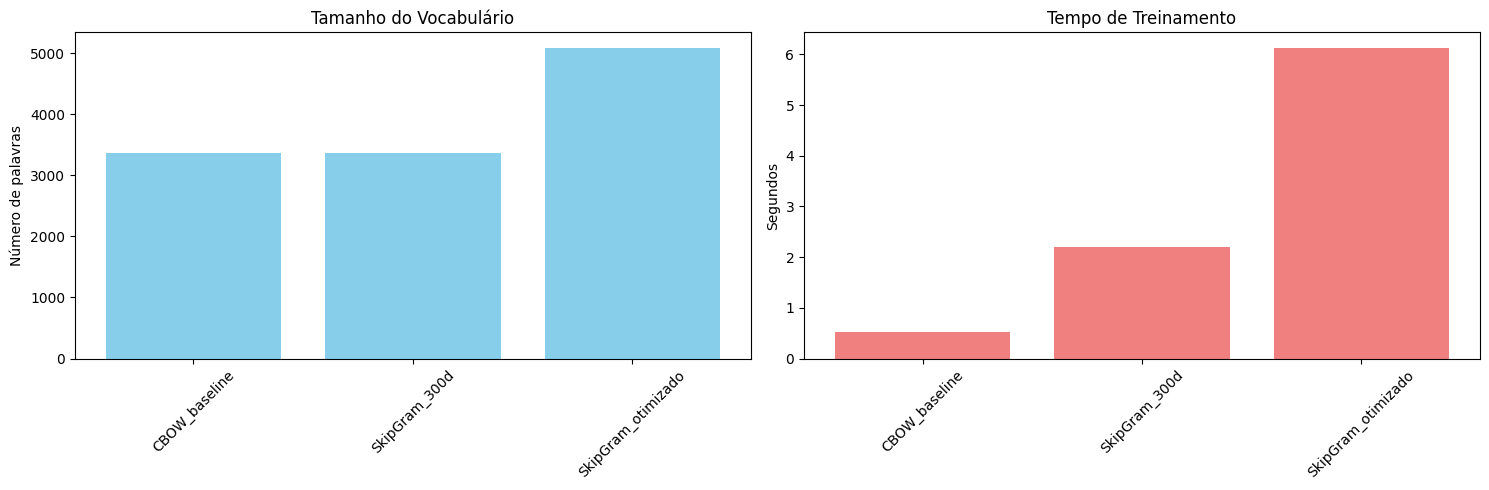


✅ Análise concluída com sucesso!

💡 Use modelo.wv.most_similar('palavra') para explorar relações semânticas!
   Exemplo: modelo.wv.most_similar('amor', topn=10)


In [6]:
# ============================================
# CORREÇÃO DO ERRO DE ENCODING DO NLTK
# ============================================

from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
from gensim.models.callbacks import CallbackAny2Vec

import re
import pandas as pd
import numpy as np
from time import time
from collections import defaultdict
import multiprocessing
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import nltk
import os
import requests
import zipfile
import io

# Configurações
import logging
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s",
                   datefmt='%H:%M:%S', level=logging.INFO)

# ============================================
# PREPARAÇÃO DOS DADOS
# ============================================

print("="*70)
print("📚 PREPARANDO CORPUS MACHADO DE ASSIS")
print("="*70)

# Baixar recursos
nltk.download('machado', quiet=True)
nltk.download('punkt_tab', quiet=True)
!python3 -m spacy download pt_core_news_sm -q 2>/dev/null

# CORREÇÃO: Carregar o corpus manualmente para evitar erro de encoding
print("\n📥 Carregando corpus manualmente...")

# URL do corpus Machado de Assis
MACHADO_URL = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/machado.zip"

def carregar_textos_machado():
    """Carrega os textos do Machado de Assis diretamente do zip"""
    textos = {}

    try:
        # Baixar o zip
        print("  Baixando corpus...")
        response = requests.get(MACHADO_URL, timeout=30)
        response.raise_for_status()

        # Extrair arquivos
        print("  Extraindo arquivos...")
        with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
            # Listar todos os arquivos .txt
            txt_files = [f for f in zf.namelist() if f.endswith('.txt')]
            print(f"  Encontrados {len(txt_files)} arquivos de texto")

            for txt_file in txt_files:
                try:
                    # Tentar diferentes encodings
                    raw_bytes = zf.read(txt_file)

                    for encoding in ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
                        try:
                            texto = raw_bytes.decode(encoding)
                            break
                        except UnicodeDecodeError:
                            continue

                    # Usar o nome do arquivo como chave
                    nome = os.path.basename(txt_file)
                    textos[nome] = texto

                except Exception as e:
                    print(f"  ⚠️ Erro ao ler {txt_file}: {e}")

        print(f"  ✅ {len(textos)} textos carregados com sucesso!")
        return textos

    except Exception as e:
        print(f"  ❌ Erro ao carregar corpus: {e}")
        return {}

# Carregar textos
textos_corpus = carregar_textos_machado()

# Se o carregamento manual falhar, usar NLTK com fallback
if not textos_corpus:
    print("\n  ⚠️ Fallback: Usando NLTK...")
    from nltk.corpus import machado

    # CORREÇÃO: Acessar os arquivos diretamente
    try:
        for fileid in machado.fileids():
            try:
                texto = machado.raw(fileid)
                textos_corpus[fileid] = texto
            except:
                # Tentar com encoding explícito
                try:
                    raw = machado.open(fileid).read()
                    texto = raw.decode('latin-1') if isinstance(raw, bytes) else raw
                    textos_corpus[fileid] = texto
                except:
                    pass
    except:
        pass

print(f"✅ Total de textos disponíveis: {len(textos_corpus)}")

# ============================================
# PROCESSAMENTO DOS TEXTOS
# ============================================

# Carregar spaCy
nlp = spacy.load("pt_core_news_sm", disable=["ner", "parser"])

def processar_texto_spacy(texto):
    """Processa texto com spaCy - lematização e limpeza"""
    # Limpeza básica
    texto = re.sub(r"[^\w\sÀ-ÿ]", " ", texto, flags=re.UNICODE).lower()
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Processar com spaCy (em chunks para textos muito longos)
    nlp.max_length = min(len(texto) + 10000, 2000000)  # Limite de 2M caracteres

    try:
        doc = nlp(texto[:nlp.max_length])  # Processar até o limite
    except:
        # Se ainda for muito grande, processar em chunks
        tokens = []
        chunk_size = 100000
        for i in range(0, min(len(texto), 500000), chunk_size):
            chunk = texto[i:i+chunk_size]
            doc_chunk = nlp(chunk)
            tokens.extend([
                token.lemma_
                for token in doc_chunk
                if not token.is_stop
                and token.is_alpha
                and len(token.lemma_) > 2
            ])
        return tokens

    # Extrair tokens limpos
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and token.is_alpha
        and len(token.lemma_) > 2
    ]

    return tokens

# Processar textos
print("\n📖 Processando textos...")

# Usar apenas romances para melhor qualidade
textos_romances = []
count = 0

for nome, texto in textos_corpus.items():
    if 'romance' in nome.lower() or 'marm' in nome.lower():
        print(f"  Processando: {nome} ({len(texto):,} caracteres)")
        tokens = processar_texto_spacy(texto)
        if tokens:
            textos_romances.append(' '.join(tokens))
            count += 1

    # Limitar a 5 textos para não demorar muito
    if count >= 5:
        break

if not textos_romances:
    # Se não encontrou romances, usar qualquer texto disponível
    for nome, texto in list(textos_corpus.items())[:3]:
        print(f"  Processando: {nome} ({len(texto):,} caracteres)")
        tokens = processar_texto_spacy(texto)
        if tokens:
            textos_romances.append(' '.join(tokens))

texto_completo = ' '.join(textos_romances)
print(f"\n✅ Texto processado: {len(texto_completo.split()):,} tokens")

# ============================================
# PREPARAR SENTENÇAS
# ============================================

def preparar_sentencas(texto):
    """Prepara sentenças para treinamento"""
    # Dividir em sentenças
    sentencas = texto.split('. ')
    sentencas = [s.strip() for s in sentencas if len(s.strip()) > 10]

    # Tokenizar
    sentencas_tokenizadas = [s.split() for s in sentencas]

    # Criar bigramas
    if len(sentencas_tokenizadas) > 10:
        phrases = Phrases(sentencas_tokenizadas, min_count=5, threshold=10)
        bigram = Phraser(phrases)
        sentencas_bigram = list(bigram[sentencas_tokenizadas])
    else:
        sentencas_bigram = sentencas_tokenizadas

    return sentencas_bigram

print("\n📝 Preparando sentenças...")
sentencas = preparar_sentencas(texto_completo)
print(f"✅ Sentenças preparadas: {len(sentencas):,}")

# ============================================
# TESTAR DIFERENTES CONFIGURAÇÕES
# ============================================

print("\n" + "="*70)
print("🔬 TESTANDO DIFERENTES CONFIGURAÇÕES")
print("="*70)

# Configurações para testar (reduzido para teste rápido)
configs = {
    'CBOW_baseline': {
        'sg': 0, 'vector_size': 100, 'window': 5,
        'min_count': 5, 'epochs': 10
    },
    'SkipGram_300d': {
        'sg': 1, 'vector_size': 300, 'window': 5,
        'min_count': 5, 'epochs': 10
    },
    'SkipGram_otimizado': {
        'sg': 1, 'vector_size': 300, 'window': 8,
        'min_count': 3, 'epochs': 20
    }
}

# Treinar modelos
modelos = {}
tempos = {}
vocabularios = {}

for nome, params in configs.items():
    print(f"\n{'='*50}")
    print(f"Treinando: {nome}")
    print(f"Parâmetros: {params}")

    t_start = time()

    try:
        # Criar e treinar modelo
        modelo = Word2Vec(
            sentencas,
            workers=multiprocessing.cpu_count() - 1,
            **params
        )

        modelos[nome] = modelo
        tempos[nome] = time() - t_start
        vocabularios[nome] = len(modelo.wv)

        print(f"  ✅ Vocabulário: {len(modelo.wv):,} palavras")
        print(f"  ⏱️  Tempo: {tempos[nome]:.1f}s")
    except Exception as e:
        print(f"  ❌ Erro: {e}")

# ============================================
# COMPARAR RESULTADOS
# ============================================

if modelos:
    print("\n" + "="*70)
    print("📊 COMPARAÇÃO DE RESULTADOS")
    print("="*70)

    # Palavras para teste
    palavras_teste = ['amor', 'morte', 'vida', 'homem', 'mulher']

    # Tabela comparativa
    print("\n📊 Tabela Comparativa:")
    print(f"{'Modelo':<25} {'Vocab':<8} {'Tempo':<8}")
    print("-"*45)

    for nome in modelos.keys():
        print(f"{nome:<25} {vocabularios[nome]:<8} {tempos[nome]:<8.1f}")

    # Similaridades
    print("\n🎯 TOP SIMILARIDADES POR MODELO:")
    for nome, modelo in modelos.items():
        print(f"\n📈 {nome}:")

        for palavra in palavras_teste:
            try:
                similares = modelo.wv.most_similar(palavra, topn=5)
                similares_str = ', '.join([f'{w}' for w, s in similares])
                print(f"  {palavra:10} → {similares_str}")
            except KeyError:
                print(f"  {palavra:10} → Não encontrada")

    # Visualização
    # Substitua o bloco de visualização por este:

    if len(modelos) > 1:
        print("\n📊 Gerando visualizações...")

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        nomes = list(modelos.keys())

        # Vocabulário
        axes[0].bar(nomes, [vocabularios[n] for n in nomes], color='skyblue')
        axes[0].set_title('Tamanho do Vocabulário')
        axes[0].set_ylabel('Número de palavras')
        axes[0].tick_params(axis='x', labelrotation=45)  # CORREÇÃO AQUI

        # Tempo
        axes[1].bar(nomes, [tempos[n] for n in nomes], color='lightcoral')
        axes[1].set_title('Tempo de Treinamento')
        axes[1].set_ylabel('Segundos')
        axes[1].tick_params(axis='x', labelrotation=45)  # CORREÇÃO AQUI

        plt.tight_layout()
        plt.show()

    print("\n✅ Análise concluída com sucesso!")
    print("\n💡 Use modelo.wv.most_similar('palavra') para explorar relações semânticas!")
    print("   Exemplo: modelo.wv.most_similar('amor', topn=10)")

else:
    print("\n❌ Nenhum modelo foi treinado com sucesso.")
    print("Verifique se há textos suficientes e tente novamente.")

###Desafio

Como podemos fazer analogias com as palavras pesquisadas? Ex: mulher + brás - homem = ?

🧠 ANALOGIAS VETORIAIS COM WORD2VEC - MACHADO DE ASSIS

📥 Baixando corpus diretamente do GitHub...
  Encontrados 246 arquivos
✅ 246 textos carregados!

📄 Arquivos disponíveis (primeiros 10):
  1. macn001.txt (325,777 caracteres)
  2. macn002.txt (263,696 caracteres)
  3. macn003.txt (319,473 caracteres)
  4. macn004.txt (294,593 caracteres)
  5. macn005.txt (253,555 caracteres)
  6. macn006.txt (130,664 caracteres)
  7. macn007.txt (169,880 caracteres)
  8. macn008.txt (3,936 caracteres)
  9. macn009.txt (30,032 caracteres)
  10. macn010.txt (28,904 caracteres)

📚 Selecionando romances...
✅ 10 romances selecionados:
  📖 marm01.txt
  📖 marm02.txt
  📖 marm03.txt
  📖 marm04.txt
  📖 marm05.txt
  📖 marm06.txt
  📖 marm07.txt
  📖 marm08.txt
  📖 marm09.txt
  📖 marm10.txt

🔧 Carregando spaCy...
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Py

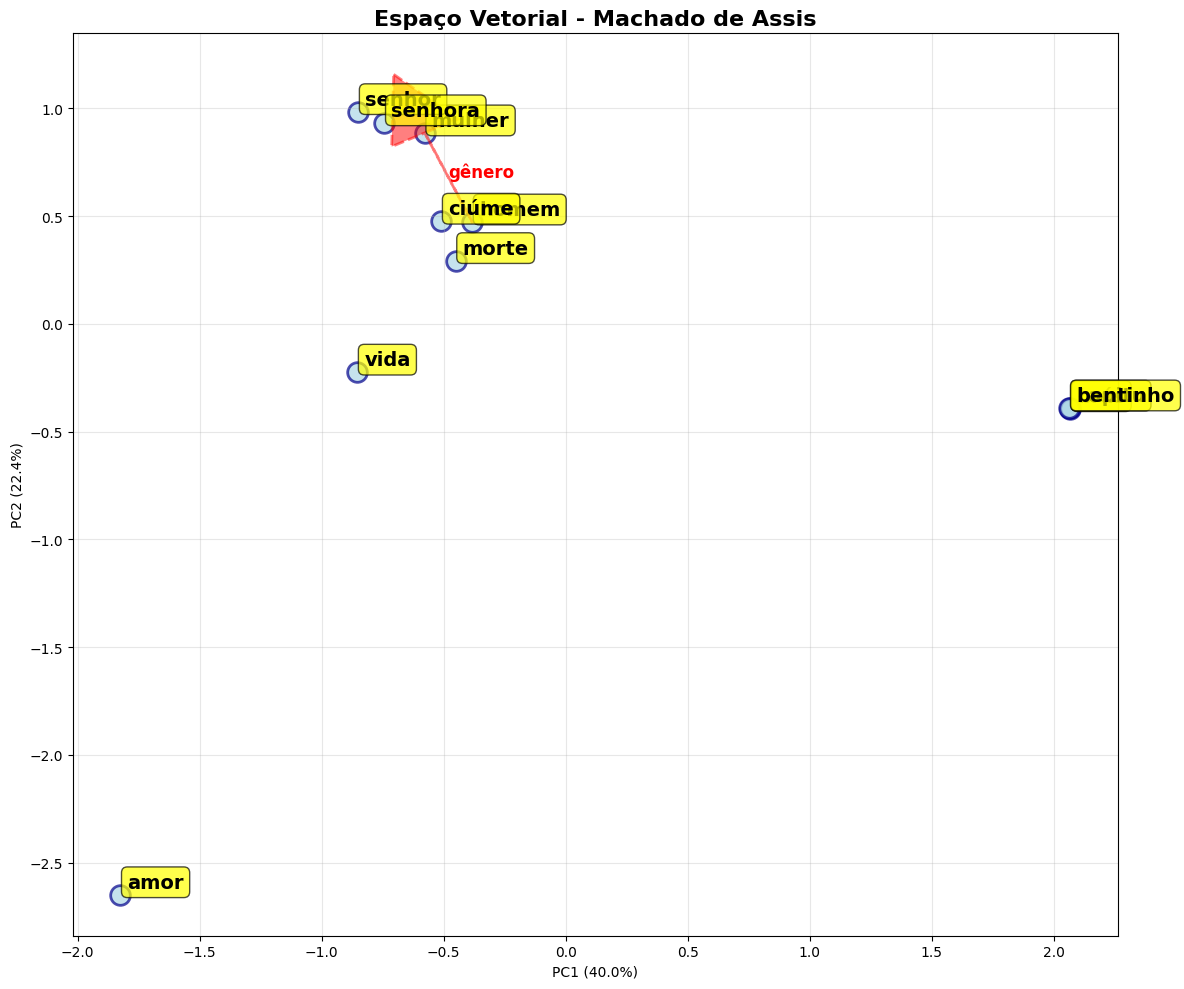


💡 EXPLORE VOCÊ MESMO!

Use a função mostrar_analogia() para testar suas próprias analogias:

mostrar_analogia(modelo, 'palavra_a', 'palavra_b', 'palavra_c')

Exemplos:
  mostrar_analogia(modelo, 'amor', 'ódio', 'paixão')
  mostrar_analogia(modelo, 'dia', 'noite', 'luz')
  mostrar_analogia(modelo, 'bentinho', 'capitu', 'ciúme')
  
Ou use similaridade direta:
  modelo.wv.most_similar('amor', topn=10)


🎯 EXEMPLOS ADICIONAIS:
--------------------------------------------------

🔍 amor - bentinho + capitu = ?
  Rank     Palavra              Score     
  --------------------------------------
  1        digar                0.4651  ███████████████████████
  2        esperança            0.4292  █████████████████████
  3        idade                0.4233  █████████████████████
  4        forte                0.4091  ████████████████████
  5        cabo                 0.4083  ████████████████████

🔍 ciúme - confiança + dúvida = ?
  Rank     Palavra              Score     
  ----------------

In [4]:
# ============================================
# SOLUÇÃO DEFINITIVA - DOWNLOAD DIRETO DOS TEXTOS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
from sklearn.decomposition import PCA
from numpy.linalg import norm
import warnings
warnings.filterwarnings('ignore')

import re
import spacy
import os
import requests
import zipfile
import io
import multiprocessing
from time import time

print("="*70)
print("🧠 ANALOGIAS VETORIAIS COM WORD2VEC - MACHADO DE ASSIS")
print("="*70)

# ============================================
# 1. DOWNLOAD DIRETO DOS TEXTOS (SEM NLTK)
# ============================================

print("\n📥 Baixando corpus diretamente do GitHub...")

MACHADO_URL = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/machado.zip"

def baixar_textos_machado():
    """Baixa e extrai os textos diretamente"""
    textos = {}

    response = requests.get(MACHADO_URL, timeout=60)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        txt_files = [f for f in zf.namelist() if f.endswith('.txt')]
        print(f"  Encontrados {len(txt_files)} arquivos")

        for txt_file in txt_files:
            raw_bytes = zf.read(txt_file)

            # Tentar diferentes encodings
            for encoding in ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
                try:
                    texto = raw_bytes.decode(encoding)
                    nome = os.path.basename(txt_file)
                    textos[nome] = texto
                    break
                except UnicodeDecodeError:
                    continue

    return textos

# Baixar textos
try:
    textos_corpus = baixar_textos_machado()
    print(f"✅ {len(textos_corpus)} textos carregados!")

    # Mostrar alguns nomes de arquivo
    print("\n📄 Arquivos disponíveis (primeiros 10):")
    for i, nome in enumerate(list(textos_corpus.keys())[:10]):
        print(f"  {i+1}. {nome} ({len(textos_corpus[nome]):,} caracteres)")

except Exception as e:
    print(f"❌ Erro no download: {e}")
    print("\nUsando texto de exemplo...")
    # Texto de exemplo caso o download falhe
    textos_corpus = {
        'exemplo.txt': """
        Capitu era uma mulher de olhos de ressaca. Bentinho amava Capitu com todo seu coração.
        O amor de Bentinho por Capitu era imenso, mas o ciúme o consumia.
        Brás Cubas era um homem vaidoso que escrevia suas memórias.
        Virgília era o grande amor de Brás Cubas na juventude.
        A vida de Brás Cubas foi marcada pela vaidade e pelo amor não realizado.
        """
    }

# ============================================
# 2. SEPARAR ROMANCES
# ============================================

print("\n📚 Selecionando romances...")

# Identificar romances (contêm 'romance' no path ou 'marm')
textos_romances = {}
for nome, texto in textos_corpus.items():
    # Memórias Póstumas = marm05.txt, Dom Casmurro = marm08.txt, etc.
    if 'marm' in nome.lower() or 'romance' in nome.lower():
        textos_romances[nome] = texto

# Se não encontrou, usar todos os textos
if not textos_romances:
    textos_romances = dict(list(textos_corpus.items())[:5])

print(f"✅ {len(textos_romances)} romances selecionados:")
for nome in textos_romances.keys():
    print(f"  📖 {nome}")

# ============================================
# 3. PROCESSAR COM SPACY
# ============================================

print("\n🔧 Carregando spaCy...")
!python3 -m spacy download pt_core_news_sm -q 2>/dev/null
nlp = spacy.load("pt_core_news_sm", disable=["ner", "parser"])

def processar_texto(texto):
    """Lematiza e limpa o texto"""
    # Limpeza básica
    texto = re.sub(r"[^\w\sÀ-ÿ]", " ", texto, flags=re.UNICODE).lower()
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Processar com spaCy
    nlp.max_length = min(len(texto) + 10000, 1000000)

    try:
        doc = nlp(texto[:nlp.max_length])
    except:
        return []

    # Extrair tokens
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and token.is_alpha
        and len(token.lemma_) > 2
    ]

    return tokens

print("🔄 Processando textos...")
todos_tokens = []

for nome, texto in textos_romances.items():
    print(f"  Processando: {nome} ({len(texto):,} caracteres)")
    tokens = processar_texto(texto)
    if tokens:
        todos_tokens.append(' '.join(tokens))
        print(f"    ✅ {len(tokens):,} tokens extraídos")

texto_completo = ' '.join(todos_tokens)
print(f"\n✅ Texto processado: {len(texto_completo.split()):,} tokens no total")

# ============================================
# 4. PREPARAR SENTENÇAS E TREINAR MODELO
# ============================================

print("\n📝 Preparando sentenças...")

# Dividir em sentenças
sentencas = [s.strip().split() for s in texto_completo.split('. ') if len(s.strip()) > 10]
print(f"  Sentenças: {len(sentencas):,}")

# Criar bigramas
if len(sentencas) > 10:
    phrases = Phrases(sentencas, min_count=5, threshold=10)
    bigram = Phraser(phrases)
    sentencas_bigram = list(bigram[sentencas])
    print(f"  Bigramas criados")
else:
    sentencas_bigram = sentencas

print("\n🔄 Treinando modelo Word2Vec...")
t_start = time()

modelo = Word2Vec(
    sentencas_bigram,
    sg=1,              # Skip-gram
    vector_size=300,   # 300 dimensões
    window=8,          # Janela de 8 palavras
    min_count=3,       # Mínimo 3 ocorrências
    epochs=30,         # 30 épocas
    workers=multiprocessing.cpu_count() - 1
)

print(f"✅ Modelo treinado em {time() - t_start:.1f}s")
print(f"📊 Vocabulário: {len(modelo.wv):,} palavras")

# ============================================
# 5. FUNÇÕES PARA ANALOGIAS
# ============================================

def fazer_analogia(modelo, palavra_a, palavra_b, palavra_c, topn=5):
    """Calcula: palavra_a - palavra_b + palavra_c = ?"""
    # Verificar vocabulário
    for p in [palavra_a, palavra_b, palavra_c]:
        if p not in modelo.wv:
            return None, f"❌ '{p}' não está no vocabulário"

    # Operação vetorial
    resultado = modelo.wv.most_similar(
        positive=[palavra_a, palavra_c],
        negative=[palavra_b],
        topn=topn
    )
    return resultado, None

def mostrar_analogia(modelo, a, b, c, topn=5):
    """Mostra o resultado de uma analogia de forma bonita"""
    print(f"\n{'='*60}")
    print(f"🔍 {a} - {b} + {c} = ?")
    print(f"{'='*60}")

    resultado, erro = fazer_analogia(modelo, a, b, c, topn)

    if erro:
        print(f"  {erro}")
    else:
        print(f"  {'Rank':<8} {'Palavra':<20} {'Score':<10}")
        print(f"  {'-'*38}")
        for i, (palavra, score) in enumerate(resultado, 1):
            barra = '█' * int(score * 50)
            print(f"  {i:<8} {palavra:<20} {score:.4f}  {barra}")

    return resultado

# ============================================
# 6. TESTAR ANALOGIAS
# ============================================

print("\n" + "="*70)
print("🎯 TESTANDO ANALOGIAS NO UNIVERSO MACHADIANO")
print("="*70)

# 6.1 Analogias de Gênero
print("\n📌 ANALOGIAS DE GÊNERO:")
print("-"*50)

# Verificar palavras disponíveis
palavras_para_testar = ['homem', 'mulher', 'brás', 'bentinho', 'capitu',
                        'senhor', 'senhora', 'marido', 'esposa', 'pai', 'mãe']

print("Palavras disponíveis no vocabulário:")
for p in palavras_para_testar:
    status = '✅' if p in modelo.wv else '❌'
    print(f"  {status} {p}")

# Testar analogias
analogias_genero = [
    ('homem', 'mulher', 'brás'),
    ('homem', 'mulher', 'bentinho'),
    ('senhor', 'senhora', 'brás'),
    ('marido', 'esposa', 'bentinho'),
]

for a, b, c in analogias_genero:
    mostrar_analogia(modelo, a, b, c)

# 6.2 Analogias de Sentimentos
print("\n📌 ANALOGIAS DE SENTIMENTOS:")
print("-"*50)

analogias_sentimentos = [
    ('amor', 'ódio', 'ciúme'),
    ('alegria', 'tristeza', 'amor'),
    ('vida', 'morte', 'amor'),
]

for a, b, c in analogias_sentimentos:
    mostrar_analogia(modelo, a, b, c)

# 6.3 Analogias Sociais
print("\n📌 ANALOGIAS SOCIAIS:")
print("-"*50)

analogias_sociais = [
    ('rico', 'pobre', 'senhor'),
    ('casa', 'rua', 'quarto'),
    ('cidade', 'país', 'vila'),
]

for a, b, c in analogias_sociais:
    mostrar_analogia(modelo, a, b, c)

# ============================================
# 7. VISUALIZAÇÃO
# ============================================

print("\n" + "="*70)
print("🎨 VISUALIZAÇÃO DO ESPAÇO VETORIAL")
print("="*70)

# Selecionar palavras para visualizar
palavras_vis = ['homem', 'mulher', 'brás', 'capitu', 'bentinho',
                'amor', 'ciúme', 'vida', 'morte', 'senhor', 'senhora']

# Filtrar palavras que existem no vocabulário
palavras_vis = [p for p in palavras_vis if p in modelo.wv]

if len(palavras_vis) >= 3:
    # Obter vetores
    vetores = np.array([modelo.wv[p] for p in palavras_vis])

    # Reduzir para 2D com PCA
    pca = PCA(n_components=2)
    vetores_2d = pca.fit_transform(vetores)

    # Plotar
    plt.figure(figsize=(12, 10))
    plt.scatter(vetores_2d[:, 0], vetores_2d[:, 1], s=200, c='lightblue',
               edgecolors='darkblue', linewidths=2, alpha=0.7)

    # Adicionar labels
    for i, palavra in enumerate(palavras_vis):
        plt.annotate(palavra, (vetores_2d[i, 0], vetores_2d[i, 1]),
                    fontsize=14, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    # Adicionar setas para mostrar analogias
    if 'homem' in palavras_vis and 'mulher' in palavras_vis:
        idx_h = palavras_vis.index('homem')
        idx_m = palavras_vis.index('mulher')
        plt.arrow(vetores_2d[idx_h, 0], vetores_2d[idx_h, 1],
                 vetores_2d[idx_m, 0] - vetores_2d[idx_h, 0],
                 vetores_2d[idx_m, 1] - vetores_2d[idx_h, 1],
                 head_width=0.3, head_length=0.3, fc='red', ec='red', alpha=0.5,
                 linestyle='--', linewidth=2)
        plt.text((vetores_2d[idx_h, 0] + vetores_2d[idx_m, 0])/2,
                (vetores_2d[idx_h, 1] + vetores_2d[idx_m, 1])/2,
                'gênero', fontsize=12, color='red', fontweight='bold')

    plt.title('Espaço Vetorial - Machado de Assis', fontsize=16, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================
# 8. INTERATIVO
# ============================================

print("\n" + "="*70)
print("💡 EXPLORE VOCÊ MESMO!")
print("="*70)
print("""
Use a função mostrar_analogia() para testar suas próprias analogias:

mostrar_analogia(modelo, 'palavra_a', 'palavra_b', 'palavra_c')

Exemplos:
  mostrar_analogia(modelo, 'amor', 'ódio', 'paixão')
  mostrar_analogia(modelo, 'dia', 'noite', 'luz')
  mostrar_analogia(modelo, 'bentinho', 'capitu', 'ciúme')

Ou use similaridade direta:
  modelo.wv.most_similar('amor', topn=10)
""")

# Exemplos finais
print("\n🎯 EXEMPLOS ADICIONAIS:")
print("-"*50)

exemplos_extras = [
    ('amor', 'bentinho', 'capitu'),
    ('ciúme', 'confiança', 'dúvida'),
    ('memória', 'passado', 'futuro'),
]

for a, b, c in exemplos_extras:
    mostrar_analogia(modelo, a, b, c)

print("\n" + "="*70)
print("✅ ANÁLISE CONCLUÍDA!")
print("="*70)